<a href="https://colab.research.google.com/github/vani-max/CNN_Model_Project/blob/main/AIStudio2A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage 2A — Mini Technical Challenge : CNN on CIFAR-10 Dataset**

In [18]:
import tensorflow as tf, keras
from tensorflow.keras import datasets, layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np

# **Dataset Overview**

In [19]:
(X_train,y_train) , (X_test, y_test)=  datasets.cifar10.load_data()

In [20]:
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [6]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [7]:
classes[1]

'automobile'

In [8]:
def show(X,y,index):
  plt.figure(figsize=(15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

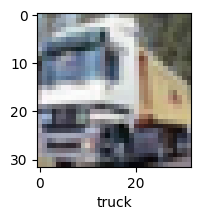

In [9]:
show(X_train,y_train,1)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
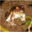

In [10]:
X_train[0]

In [11]:
X_train = X_train/255.0
X_test = X_test/255.0

# **Baseline Model: Artificial Neural Network (ANN)**

In [12]:
model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation='relu'),
    layers.Dense(1000,activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 289s 230ms/step - accuracy: 0.3140 - loss: 1.9228 - val_accuracy: 0.3432 - val_loss: 1.8115
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 271s 217ms/step - accuracy: 0.3928 - loss: 1.6829 - val_accuracy: 0.4101 - val_loss: 1.6778
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 289s 231ms/step - accuracy: 0.4266 - loss: 1.6049 - val_accuracy: 0.4279 - val_loss: 1.6132
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 312s 223ms/step - accuracy: 0.4469 - loss: 1.5472 - val_accuracy: 0.4306 - val_loss: 1.5888
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 326s 226ms/step - accuracy: 0.4602 - loss: 1.5106 - val_accuracy: 0.4487 - val_loss: 1.5657
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 287s 230ms/step - accuracy: 0.4676 - loss: 1.4834 - val_accuracy: 0.4487 - val_loss: 1.5549
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 290s 232ms/step - accuracy: 0.4775 - loss: 1.4562 - val_accuracy: 0.4539 - val_loss: 1.5530
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 282s 226ms/step - ac

In [21]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.3855 - loss: 252.3914


[252.39144897460938, 0.3855000138282776]

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = model.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
              precision    recall  f1-score   support

           0       0.35      0.66      0.46      1000
           1       0.61      0.47      0.53      1000
           2       0.53      0.05      0.09      1000
           3       0.27      0.18      0.21      1000
           4       0.64      0.06      0.10      1000
           5       0.24      0.64      0.35      1000
           6       0.69      0.13      0.22      1000
           7       0.50      0.52      0.51      1000
           8       0.44      0.68      0.53      1000
           9       0.45      0.47      0.46      1000

    accuracy                           0.39     10000
   macro avg       0.47      0.39      0.35     10000
weighted avg       0.47      0.39      0.35     10000



# **CNN Model Architecture**

In [23]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

**CNN without dropout - Primary Model**

In [24]:
cnn_base = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_base = cnn_base.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

cnn_base.evaluate(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 46ms/step - accuracy: 0.4561 - loss: 1.5074 - val_accuracy: 0.5434 - val_loss: 1.2797
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.5943 - loss: 1.1575 - val_accuracy: 0.6144 - val_loss: 1.0969
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.6423 - loss: 1.0262 - val_accuracy: 0.6404 - val_loss: 1.0365
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.6734 - loss: 0.9434 - val_accuracy: 0.6364 - val_loss: 1.0617
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.6961 - loss: 0.8731 - val_accuracy: 0.6723 - val_loss: 0.9630
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7145 - loss: 0.8203 - val_accuracy: 0.6702 - val_loss: 0.9688
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.7309 - loss: 0.7708 - val_accuracy: 0.6866 - val_loss: 0.9227
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.7470 -

[0.9620936512947083, 0.6796000003814697]

CNN With dropout - Experiment

In [25]:
cnn = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [26]:
cnn.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [27]:
history = cnn.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.3406 - loss: 1.7816 - val_accuracy: 0.4982 - val_loss: 1.4272
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 45ms/step - accuracy: 0.4498 - loss: 1.5024 - val_accuracy: 0.5608 - val_loss: 1.2565
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.4954 - loss: 1.3857 - val_accuracy: 0.5578 - val_loss: 1.2302
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.5242 - loss: 1.3220 - val_accuracy: 0.5822 - val_loss: 1.1594
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.5436 - loss: 1.2624 - val_accuracy: 0.6192 - val_loss: 1.0967
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.5590 - loss: 1.2166 - val_accuracy: 0.6440 - val_loss: 1.0159
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.5808 - loss: 1.1675 - val_accuracy: 0.6445 - val_loss: 1.0068
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 44ms/step - accuracy: 0.5922 -

In [28]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6618 - loss: 0.9649


[0.9648682475090027, 0.6618000268936157]

In [29]:
y_test = y_test.reshape(-1,)

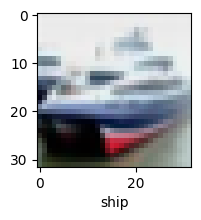

In [30]:
show(X_test, y_test,1)

In [31]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([[9.47403430e-04, 1.41527664e-04, 2.33313860e-03, 7.63098717e-01,
        3.05087096e-03, 1.89414784e-01, 3.05662658e-02, 2.34780295e-04,
        9.69495438e-03, 5.17420354e-04],
       [1.67324778e-03, 8.24231565e-01, 1.32521203e-08, 2.54630876e-08,
        5.14327025e-09, 5.15616161e-11, 1.79345719e-07, 2.38197934e-11,
        1.73761562e-01, 3.33468866e-04],
       [1.22678287e-01, 3.30265492e-01, 8.99633334e-04, 1.32411812e-03,
        8.93794233e-04, 1.30517365e-04, 1.38043123e-03, 1.95494620e-04,
        5.10358453e-01, 3.18738073e-02],
       [4.62223858e-01, 7.87872523e-02, 9.69458930e-03, 1.27937156e-03,
        5.26490575e-03, 5.67521674e-05, 1.13044039e-03, 8.14415544e-05,
        4.39464957e-01, 2.01647170e-03],
       [2.64746473e-06, 6.07618358e-06, 2.38267146e-02, 1.38890445e-02,
        1.03361093e-01, 2.46701576e-03, 8.56427133e-01, 1.80075840e-05,
        1.75510183e-06, 4.99033774e-07]], dtype=float32)

In [32]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(1), np.int64(8), np.int64(0), np.int64(6)]

In [33]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [34]:
classes[y_classes[1]]

'automobile'

In [35]:
print(classification_report(y_test, y_classes))

              precision    recall  f1-score   support

           0       0.74      0.69      0.71      1000
           1       0.78      0.84      0.81      1000
           2       0.59      0.43      0.50      1000
           3       0.44      0.44      0.44      1000
           4       0.55      0.63      0.59      1000
           5       0.56      0.53      0.55      1000
           6       0.62      0.85      0.72      1000
           7       0.76      0.70      0.73      1000
           8       0.80      0.76      0.78      1000
           9       0.82      0.73      0.77      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



CNN without Dropout - Plots

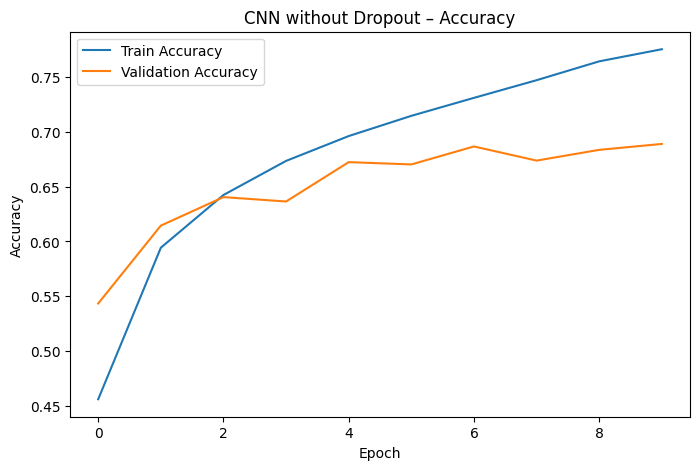

In [36]:
plt.figure(figsize=(8,5))
plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN without Dropout – Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

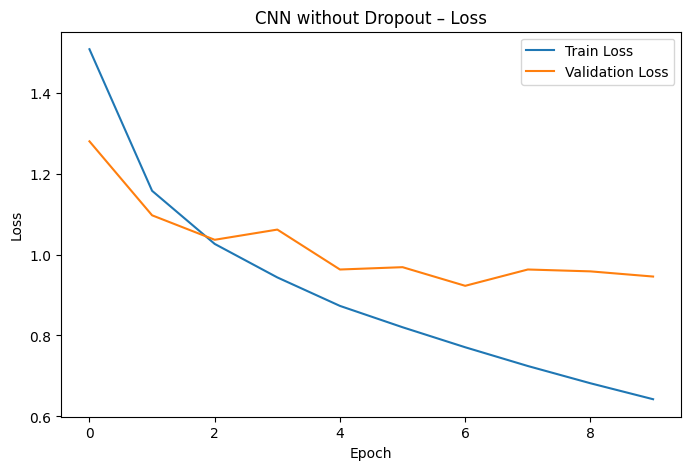

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('CNN without Dropout – Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Without Dropout, training accuracy increases faster than validation accuracy, indicating mild overfitting.

CNN With Dropout - Plot

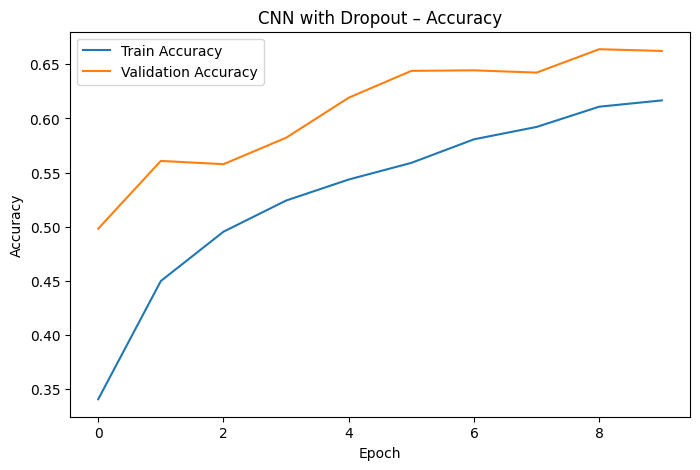

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN with Dropout – Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

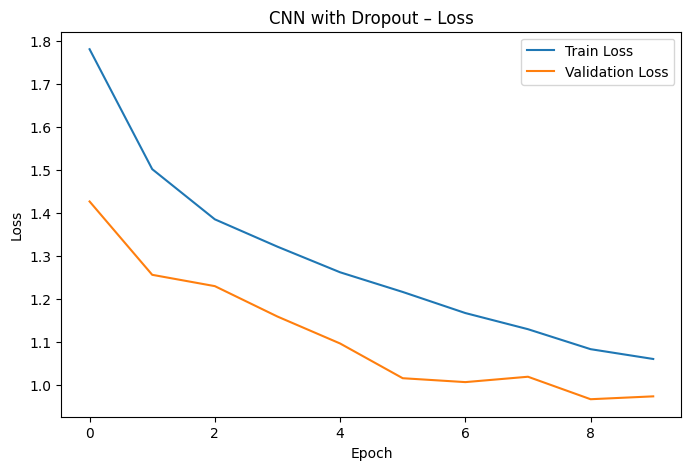

In [39]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN with Dropout – Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

With Dropout, training accuracy is lower but validation curves are smoother, suggesting improved generalization.

## Research Phase 2: Improving Generalization via Data Augmentation
To prevent the model from overfitting to the static training set, we introduce Data Augmentation. By applying random horizontal flips and slight rotations, we synthetically expand our dataset and force the network to learn invariant spatial features.

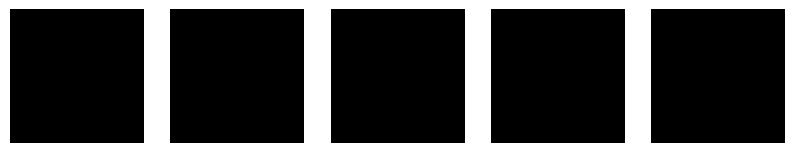

In [40]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# Visualizing an augmented image
plt.figure(figsize=(10, 2))
for i in range(5):
    augmented_image = data_augmentation(X_train[0:1])
    plt.subplot(1, 5, i+1)
    plt.imshow(augmented_image[0] / 255.0) # Ensure proper scaling for display
    plt.axis("off")

## Research Phase 3: Architectural Optimization
We now construct an advanced CNN utilizing both Batch Normalization (to stabilize internal covariate shift) and Dropout (to penalize reliance on specific neurons). We will evaluate the impact of these techniques on the stability of our validation metrics.

In [ ]:
advanced_cnn = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

advanced_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_adv = advanced_cnn.fit(X_train, y_train, epochs=15, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 99ms/step - accuracy: 0.4096 - loss: 1.7043 - val_accuracy: 0.3921 - val_loss: 1.8983
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 146s 102ms/step - accuracy: 0.5120 - loss: 1.3742 - val_accuracy: 0.5486 - val_loss: 1.3485
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 102ms/step - accuracy: 0.5465 - loss: 1.2822 - val_accuracy: 0.5950 - val_loss: 1.1546
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 125s 100ms/step - accuracy: 0.5650 - loss: 1.2304 - val_accuracy: 0.5696 - val_loss: 1.3298
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 101ms/step - accuracy: 0.5828 - loss: 1.1878 - val_accuracy: 0.5828 - val_loss: 1.2150
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 131s 105ms/step - accuracy: 0.5985 - loss: 1.1482 - val_accuracy: 0.5559 - val_loss: 1.4491
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 107ms/step - accuracy: 0.6064 - loss: 1.1275 - val_accuracy: 0.6524 - val_loss: 1.0161
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 132s 105ms/step - acc

## Research Phase 4: Interpretability and Visual Diagnostics
To ensure our model is making decisions based on relevant features rather than spurious correlations, we utilize Grad-CAM. This allows us to visually audit the spatial activation maps and the model's reasoning.